## Ejercicio de Distribución

Realice un programa que simule una configuraci ́on aleatoria de bolitas en urnas seg ́un Maxwell-Boltzmann

a) Haga el pseudocódigo con todos los detalles posibles.
b) En casa implemente el programa. Corra su programa una cantidad grande de veces dada por la usuaria, y haga un histograma de la variable $X_i$ sobre todos los posibles valores de $k$ en una urna fija $i$ cuando el total de urnas N = 25 y la cantidad de bolitas es n = 100. También de la variable $M_0$. Grafique los histogramas para un número grande de simulaciones. ¿Se parecen a los obtenidos con la fórmula en clase? Solo vale si a) es correcto y completo.

#### Solución

En Maxwell–Boltzmann, cada bolita se trata individualmente y elige una urna de manera independiente. Por eso la ocupación de una urna fija es binomial: cada bolita tiene una pequeña probabilidad de caer allí, y el total de éxitos cuenta cuántas cayeron en esa urna.

Queremos que el algoritmo:
	•	Recorra bolita por bolita
    
	•	Asigne a una urna aleatoria
    
	•	cuente ocupaciones.

Variables a estudiar:
	•	$X_i$: ocupación de una urna fija
    
	•	$M_0$: número de urnas vacías.

### Pseudo código

Leer número de simulaciones S

Fijar:
    N = 25   # número de urnas
    n = 100  # número de bolitas
    i = urna fija que se quiere estudiar

Crear lista vacía valores_Xi
Crear lista vacía valores_M0

Repetir S veces:

    Crear lista ocupaciones de tamaño N con ceros

    Para cada bolita desde 1 hasta n:
        elegir una urna al azar entre 1 y N
        aumentar en 1 la ocupación de esa urna

    Xi = número de bolitas en la urna fija i
    M0 = número de urnas cuya ocupación es 0

    guardar Xi en valores_Xi
    guardar M0 en valores_M0

Hacer histograma de valores_Xi
Hacer histograma de valores_M0


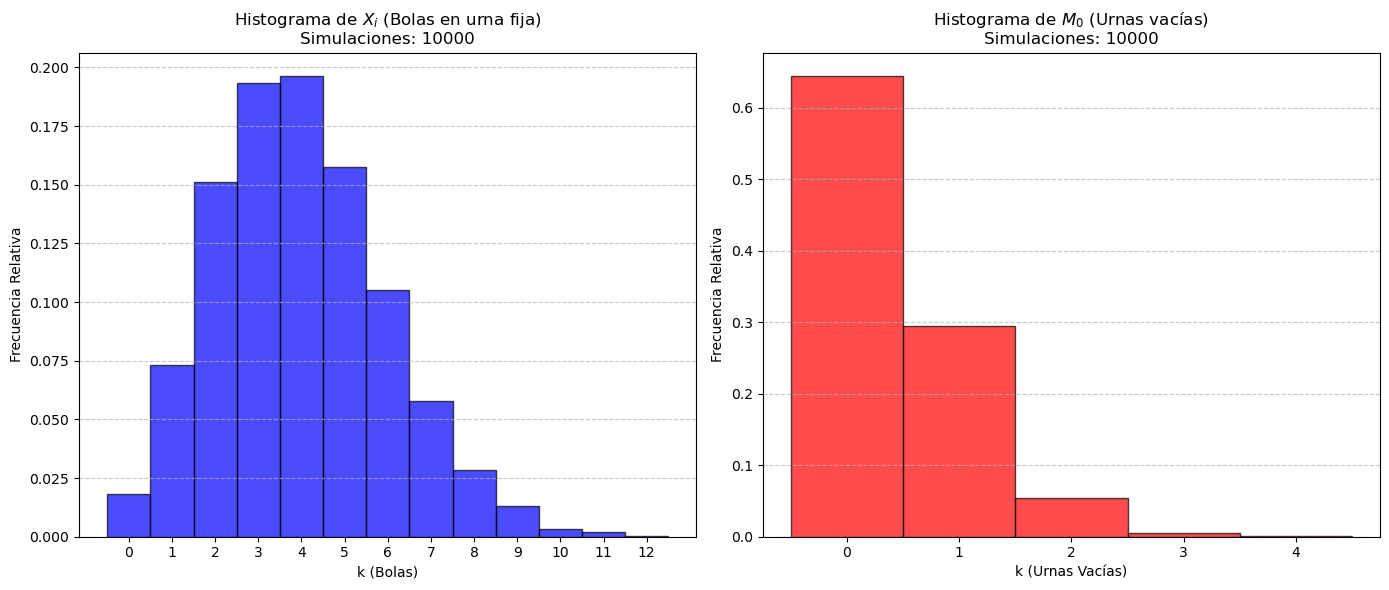

In [4]:
import random
import matplotlib.pyplot as plt
import numpy as np

N = 25  # Total de urnas
n = 100 # Total de bolitas
num_simulaciones = 10000 # Cantidad grande de veces dada por la usuaria

def simular_MB(n_bolas, N_urnas):
    urnas = [0] * N_urnas
    for _ in range(n_bolas):
        urna_elegida = random.randint(0, N_urnas - 1)
        urnas[urna_elegida] += 1
    return urnas

# Listas para guardar las variables aleatorias de cada simulación
X_i_resultados = []
M_0_resultados = []

urna_fija = 0 # Elegimos la primera urna (índice 0) como nuestra Xi

# b) Ejecutar simulaciones
for _ in range(num_simulaciones):
    configuracion = simular_MB(n, N)
    
    # Xi: Bolas en la urna fija
    X_i_resultados.append(configuracion[urna_fija])
    
    # M0: Urnas vacías
    M_0_resultados.append(configuracion.count(0))

plt.figure(figsize=(14, 6))

# Histograma para Xi
plt.subplot(1, 2, 1)
# Bins centrados en los enteros
bins_Xi = range(min(X_i_resultados), max(X_i_resultados) + 2)
plt.hist(X_i_resultados, bins=[b - 0.5 for b in bins_Xi], density=True, alpha=0.7, color='blue', edgecolor='black')
plt.title(f'Histograma de $X_i$ (Bolas en urna fija)\nSimulaciones: {num_simulaciones}')
plt.xlabel('k (Bolas)')
plt.ylabel('Frecuencia Relativa')
plt.xticks(range(min(X_i_resultados), max(X_i_resultados) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Histograma para M0
plt.subplot(1, 2, 2)
bins_M0 = range(min(M_0_resultados), max(M_0_resultados) + 2)
plt.hist(M_0_resultados, bins=[b - 0.5 for b in bins_M0], density=True, alpha=0.7, color='red', edgecolor='black')
plt.title(f'Histograma de $M_0$ (Urnas vacías)\nSimulaciones: {num_simulaciones}')
plt.xlabel('k (Urnas Vacías)')
plt.ylabel('Frecuencia Relativa')
plt.xticks(range(min(M_0_resultados), max(M_0_resultados) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

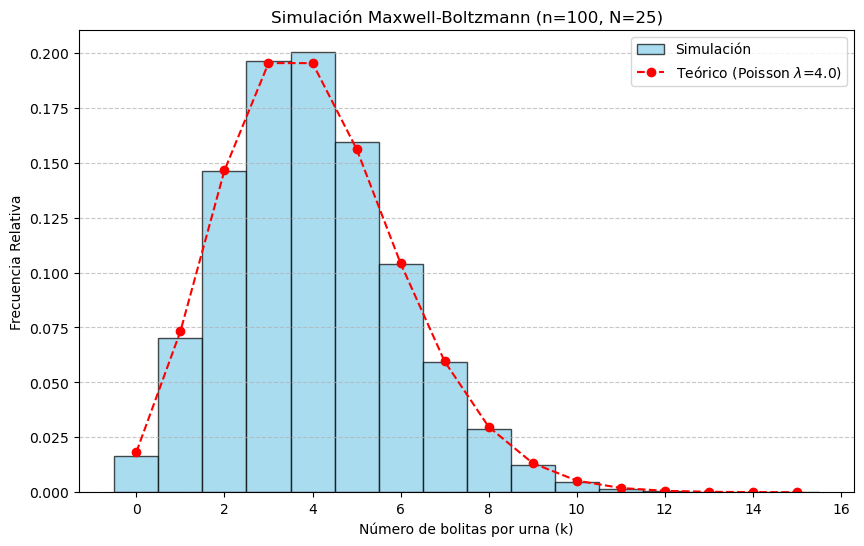

In [5]:
def simular_maxwell_boltzmann(n, N, simulations=10000):
    todas_las_ocupaciones = []
    
    for _ in range(simulations):
        # Cada bolita elige una urna al azar (Maxwell-Boltzmann: Distinguibles)
        urnas = np.random.randint(0, N, size=n)
        
        # Contamos cuántas bolitas hay en cada una de las N urnas
        conteos = np.bincount(urnas, minlength=N)
        todas_las_ocupaciones.extend(conteos)
    
    # Configuración del Histograma
    plt.figure(figsize=(10, 6))
    bins = np.arange(0, max(todas_las_ocupaciones) + 2) - 0.5
    plt.hist(todas_las_ocupaciones, bins=bins, density=True, 
             alpha=0.7, color='skyblue', edgecolor='black', label='Simulación')

    # Validación con la distribución de Poisson (Teórica para N grande)
    # Media lambda = n / N
    lam = n / N
    from scipy.stats import poisson
    k_values = np.arange(0, max(todas_las_ocupaciones) + 1)
    plt.plot(k_values, poisson.pmf(k_values, lam), 'ro--', label=rf'Teórico (Poisson $\lambda$={lam})')

    plt.title(f'Simulación Maxwell-Boltzmann (n={n}, N={N})')
    plt.xlabel('Número de bolitas por urna (k)')
    plt.ylabel('Frecuencia Relativa')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

simular_maxwell_boltzmann(n=100, N=25, simulations=10000)